# 🛒 Store Sales and Profit Analysis
### ShadowFox AIML Internship — Intermediate Task

**Goal:** Analyze retail store sales and profit data to uncover trends, identify top-performing categories, and derive actionable business insights.

---
**Dataset Columns Used:**
| Column | Description |
|--------|-------------|
| Order Date | Date the order was placed |
| Category | Product category (Furniture, Office Supplies, Technology) |
| Sub-Category | More specific product type |
| Segment | Customer type (Consumer, Corporate, Home Office) |
| Region | Geographic region (East, West, Central, South) |
| Sales | Revenue generated |
| Profit | Profit earned |
| Discount | Discount applied |

## Step 1: Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


## Step 2: Load and Prepare the Dataset

In [8]:
df = pd.read_csv(r'C:\Users\KIIT0001\Desktop\StoresSales\Sample - Superstore.csv', encoding='latin1')

print('Dataset Shape:', df.shape)
df.head()

Dataset Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [9]:
# Convert Order Date to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Extract Year and Month for time-based analysis
df['Year']       = df['Order Date'].dt.year
df['Month']      = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.strftime('%b')  # Jan, Feb, ...
df['YearMonth']  = df['Order Date'].dt.to_period('M')  # 2016-01, 2016-02...

# Add Profit Margin column
df['Profit Margin %'] = (df['Profit'] / df['Sales'] * 100).round(2)

print('✅ Date columns converted and new features added!')
print('Missing values:', df.isnull().sum().sum())
print('Date range:', df['Order Date'].min().date(), 'to', df['Order Date'].max().date())

✅ Date columns converted and new features added!
Missing values: 0
Date range: 2014-01-03 to 2017-12-30


## Step 3: Overall Summary Statistics

In [10]:
total_sales   = df['Sales'].sum()
total_profit  = df['Profit'].sum()
total_orders  = df['Order ID'].nunique()
total_customers = df['Customer ID'].nunique()
avg_margin    = (total_profit / total_sales * 100)

print('='*50)
print('       📊 BUSINESS OVERVIEW')
print('='*50)
print(f'  Total Sales      : ${total_sales:>12,.2f}')
print(f'  Total Profit     : ${total_profit:>12,.2f}')
print(f'  Profit Margin    : {avg_margin:>11.1f}%')
print(f'  Total Orders     : {total_orders:>12,}')
print(f'  Total Customers  : {total_customers:>12,}')
print('='*50)

       📊 BUSINESS OVERVIEW
  Total Sales      : $2,297,200.86
  Total Profit     : $  286,397.02
  Profit Margin    :        12.5%
  Total Orders     :        5,009
  Total Customers  :          793


## Step 4: Sales Trend Analysis (Over Time)

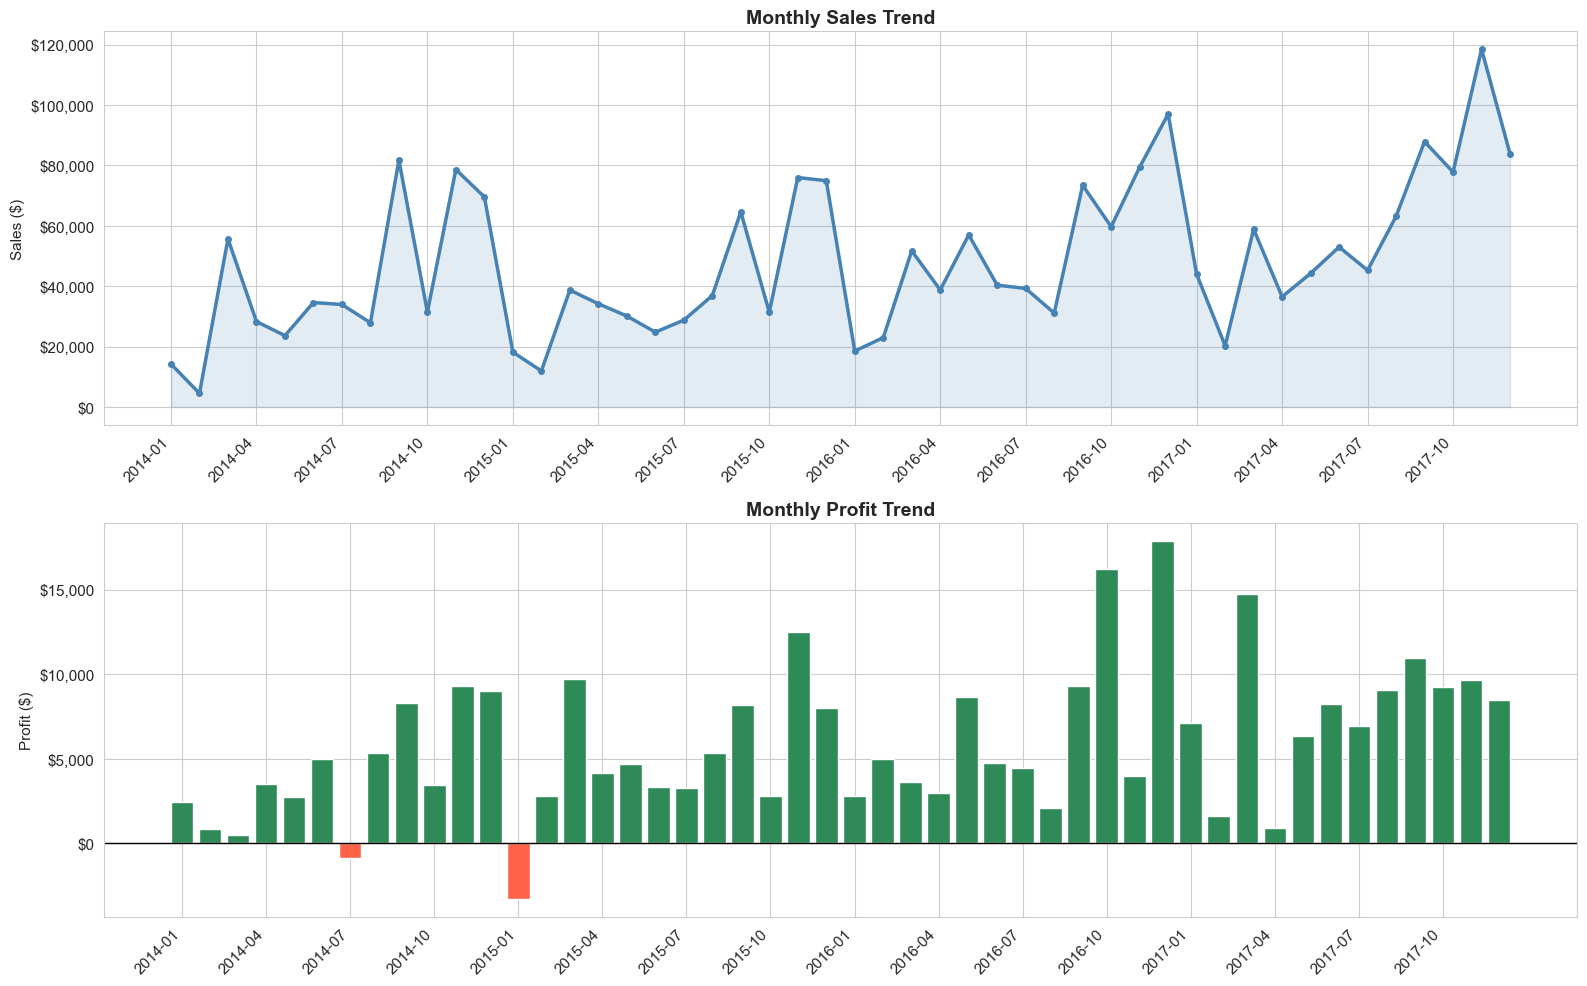

In [11]:
# Monthly sales trend
monthly = df.groupby('YearMonth')[['Sales', 'Profit']].sum().reset_index()
monthly['YearMonth_str'] = monthly['YearMonth'].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Sales line
axes[0].plot(monthly['YearMonth_str'], monthly['Sales'],
             color='steelblue', linewidth=2.5, marker='o', markersize=4)
axes[0].fill_between(range(len(monthly)), monthly['Sales'], alpha=0.15, color='steelblue')
axes[0].set_title('Monthly Sales Trend', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Sales ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].set_xticks(range(0, len(monthly), 3))
axes[0].set_xticklabels(monthly['YearMonth_str'][::3], rotation=45, ha='right')

# Profit line
colors = ['tomato' if p < 0 else 'seagreen' for p in monthly['Profit']]
axes[1].bar(range(len(monthly)), monthly['Profit'], color=colors, edgecolor='white')
axes[1].set_title('Monthly Profit Trend', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Profit ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].set_xticks(range(0, len(monthly), 3))
axes[1].set_xticklabels(monthly['YearMonth_str'][::3], rotation=45, ha='right')
axes[1].axhline(0, color='black', linewidth=1)

plt.tight_layout()
plt.show()

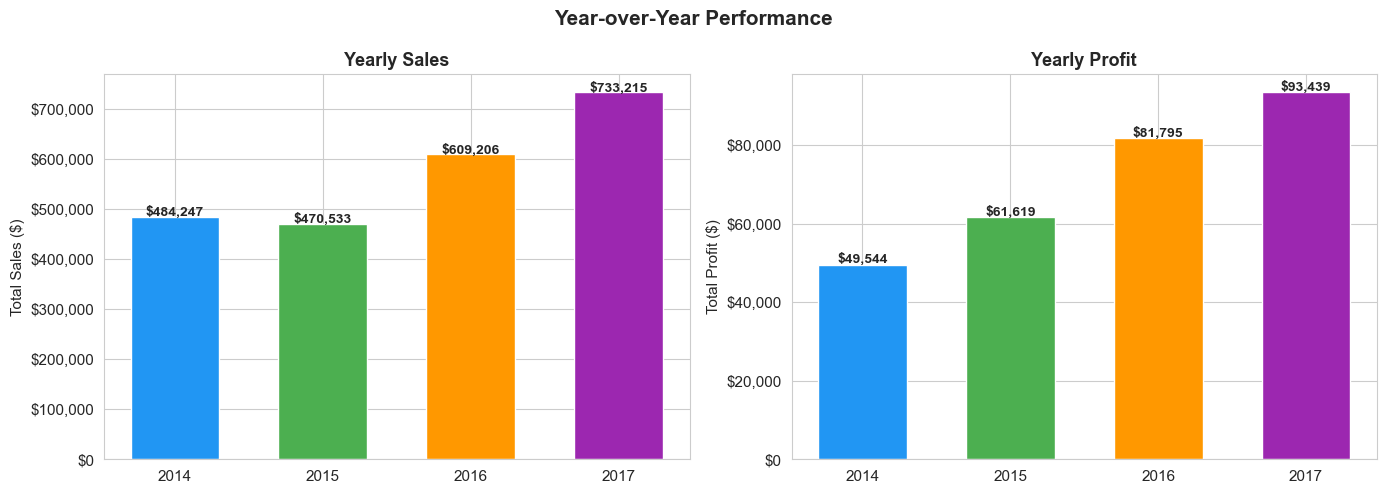

In [12]:
# Yearly comparison
yearly = df.groupby('Year')[['Sales', 'Profit']].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(yearly['Year'].astype(str), yearly['Sales'],
            color=['#2196F3','#4CAF50','#FF9800','#9C27B0'], edgecolor='white', width=0.6)
axes[0].set_title('Yearly Sales', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Total Sales ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for i, v in enumerate(yearly['Sales']):
    axes[0].text(i, v + 2000, f'${v:,.0f}', ha='center', fontsize=10, fontweight='bold')

axes[1].bar(yearly['Year'].astype(str), yearly['Profit'],
            color=['#2196F3','#4CAF50','#FF9800','#9C27B0'], edgecolor='white', width=0.6)
axes[1].set_title('Yearly Profit', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Total Profit ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for i, v in enumerate(yearly['Profit']):
    axes[1].text(i, v + 500, f'${v:,.0f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Year-over-Year Performance', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 5: Category & Sub-Category Analysis

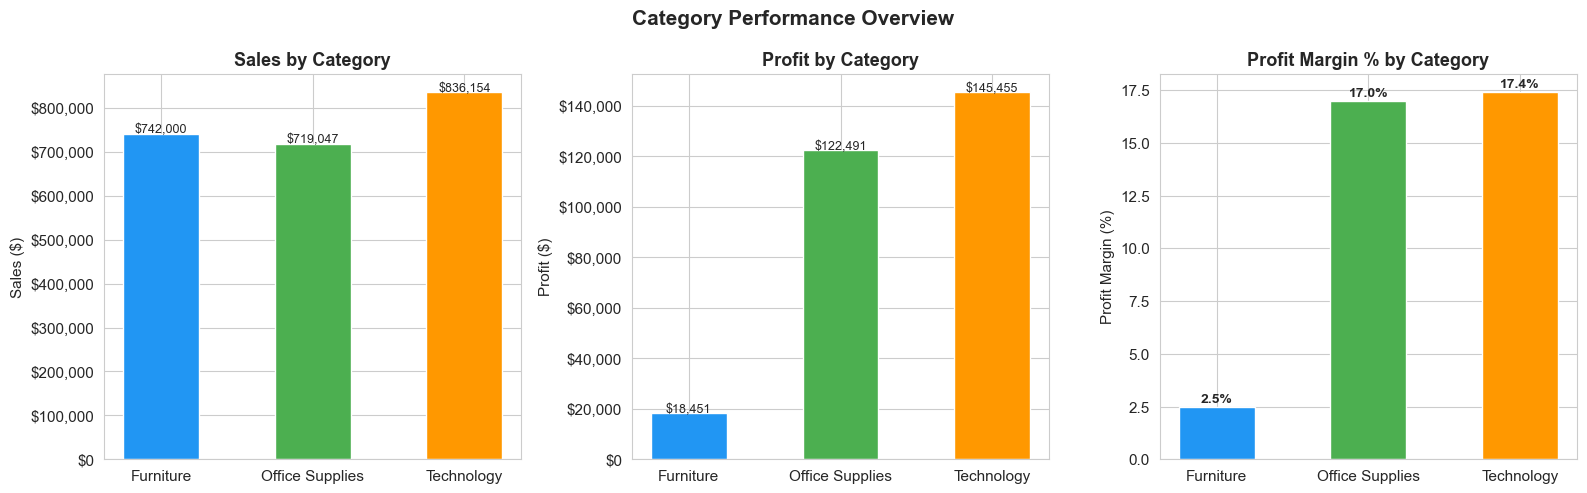

       Category       Sales      Profit  Profit Margin %
      Furniture 741999.7953  18451.2728              2.5
Office Supplies 719047.0320 122490.8008             17.0
     Technology 836154.0330 145454.9481             17.4


In [13]:
# Sales and Profit by Category
cat = df.groupby('Category')[['Sales', 'Profit']].sum().reset_index()
cat['Profit Margin %'] = (cat['Profit'] / cat['Sales'] * 100).round(1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#2196F3', '#4CAF50', '#FF9800']

# Sales by category
bars = axes[0].bar(cat['Category'], cat['Sales'], color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Sales by Category', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Sales ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar, v in zip(bars, cat['Sales']):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+2000, f'${v:,.0f}', ha='center', fontsize=9)

# Profit by category
bars2 = axes[1].bar(cat['Category'], cat['Profit'], color=colors, edgecolor='white', width=0.5)
axes[1].set_title('Profit by Category', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Profit ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar, v in zip(bars2, cat['Profit']):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+200, f'${v:,.0f}', ha='center', fontsize=9)

# Profit margin
axes[2].bar(cat['Category'], cat['Profit Margin %'], color=colors, edgecolor='white', width=0.5)
axes[2].set_title('Profit Margin % by Category', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Profit Margin (%)')
for i, v in enumerate(cat['Profit Margin %']):
    axes[2].text(i, v+0.2, f'{v}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Category Performance Overview', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print(cat.to_string(index=False))


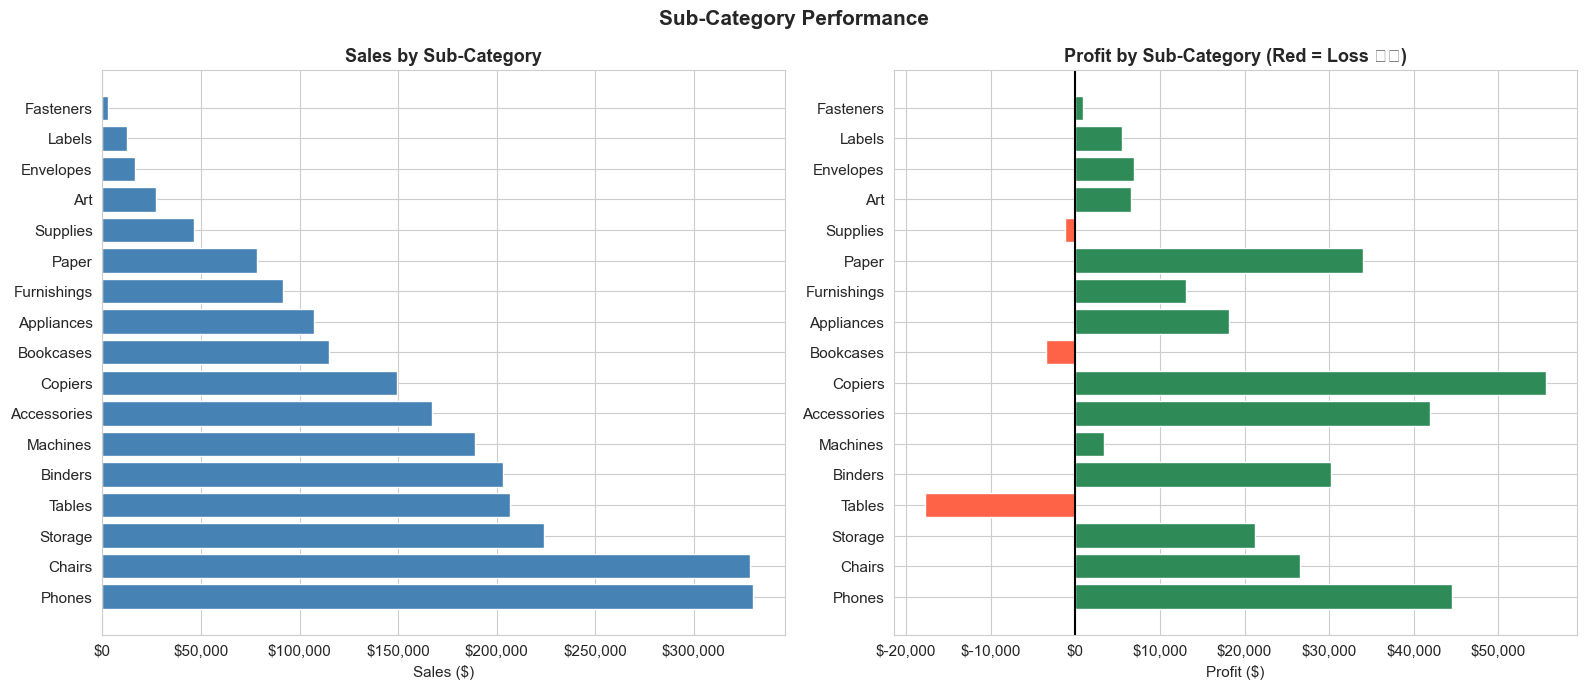

⚠️  Loss-making Sub-Categories:
Sub-Category       Sales      Profit
      Tables 206965.5320 -17725.4811
   Bookcases 114879.9963  -3472.5560
    Supplies  46673.5380  -1189.0995


In [14]:
# Sub-category deep dive
subcat = df.groupby('Sub-Category')[['Sales','Profit']].sum().reset_index()
subcat = subcat.sort_values('Sales', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Sales by sub-category
colors_s = ['tomato' if p < 0 else 'steelblue' for p in subcat['Sales']]
axes[0].barh(subcat['Sub-Category'], subcat['Sales'], color='steelblue', edgecolor='white')
axes[0].set_title('Sales by Sub-Category', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sales ($)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Profit by sub-category (red = loss, green = profit)
colors_p = ['tomato' if p < 0 else 'seagreen' for p in subcat['Profit']]
axes[1].barh(subcat['Sub-Category'], subcat['Profit'], color=colors_p, edgecolor='white')
axes[1].set_title('Profit by Sub-Category (Red = Loss ⚠️)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Profit ($)')
axes[1].axvline(0, color='black', linewidth=1.5)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Sub-Category Performance', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Show loss-making sub-categories
losses = subcat[subcat['Profit'] < 0][['Sub-Category','Sales','Profit']]
print('⚠️  Loss-making Sub-Categories:')
print(losses.to_string(index=False))

## Step 6: Customer Segment Analysis

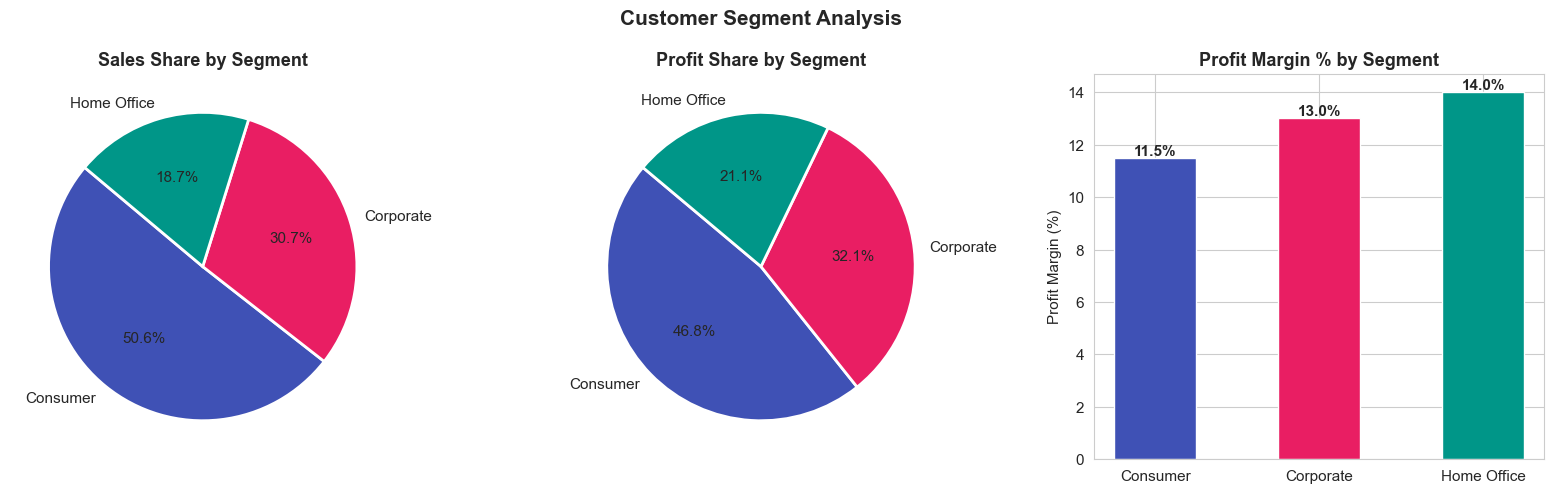

    Segment        Sales      Profit  Profit Margin %
   Consumer 1161401.3450 134119.2092             11.5
  Corporate  706146.3668  91979.1340             13.0
Home Office  429653.1485  60298.6785             14.0


In [15]:
seg = df.groupby('Segment')[['Sales','Profit']].sum().reset_index()
seg['Profit Margin %'] = (seg['Profit'] / seg['Sales'] * 100).round(1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#3F51B5', '#E91E63', '#009688']

# Pie: Sales by segment
axes[0].pie(seg['Sales'], labels=seg['Segment'], autopct='%1.1f%%',
            colors=colors, startangle=140,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Sales Share by Segment', fontsize=13, fontweight='bold')

# Pie: Profit by segment
axes[1].pie(seg['Profit'], labels=seg['Segment'], autopct='%1.1f%%',
            colors=colors, startangle=140,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Profit Share by Segment', fontsize=13, fontweight='bold')

# Bar: Profit margin
axes[2].bar(seg['Segment'], seg['Profit Margin %'], color=colors, edgecolor='white', width=0.5)
axes[2].set_title('Profit Margin % by Segment', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Profit Margin (%)')
for i, v in enumerate(seg['Profit Margin %']):
    axes[2].text(i, v+0.1, f'{v}%', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Customer Segment Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print(seg.to_string(index=False))

## Step 7: Regional Performance

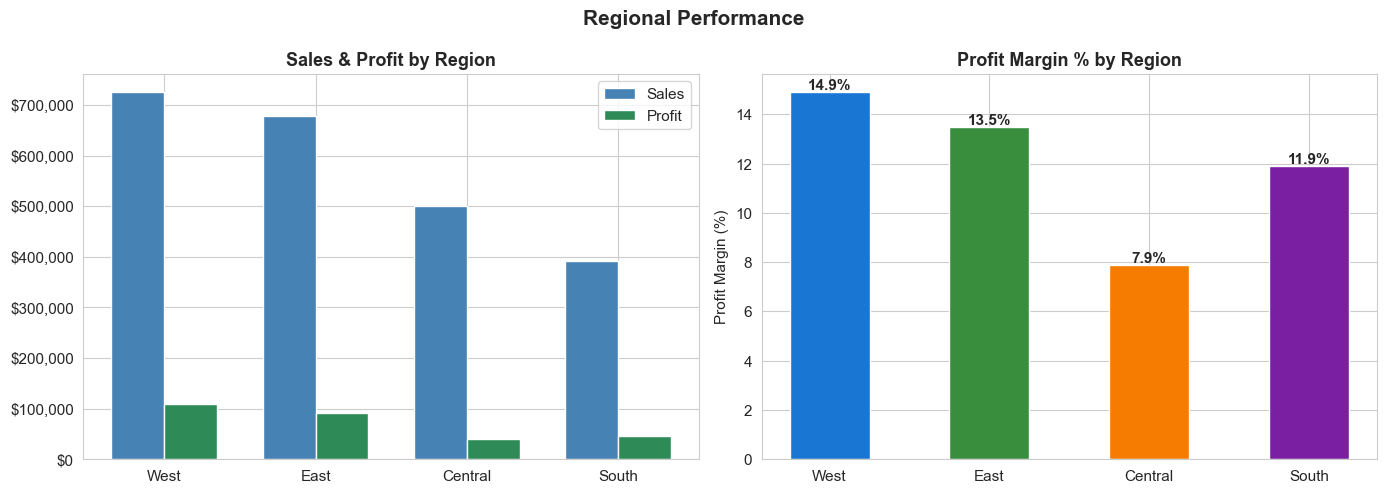

 Region       Sales      Profit  Profit Margin %
   West 725457.8245 108418.4489             14.9
   East 678781.2400  91522.7800             13.5
Central 501239.8908  39706.3625              7.9
  South 391721.9050  46749.4303             11.9


In [16]:
region = df.groupby('Region')[['Sales','Profit']].sum().reset_index().sort_values('Sales', ascending=False)
region['Profit Margin %'] = (region['Profit'] / region['Sales'] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#1976D2','#388E3C','#F57C00','#7B1FA2']

x = range(len(region))
w = 0.35
b1 = axes[0].bar([i-w/2 for i in x], region['Sales'], width=w, label='Sales', color='steelblue', edgecolor='white')
b2 = axes[0].bar([i+w/2 for i in x], region['Profit'], width=w, label='Profit', color='seagreen', edgecolor='white')
axes[0].set_title('Sales & Profit by Region', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(region['Region'])
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].legend()

axes[1].bar(region['Region'], region['Profit Margin %'], color=colors, edgecolor='white', width=0.5)
axes[1].set_title('Profit Margin % by Region', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Profit Margin (%)')
for i, v in enumerate(region['Profit Margin %']):
    axes[1].text(i, v+0.1, f'{v}%', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Regional Performance', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print(region.to_string(index=False))

## Step 8: Discount Impact on Profit

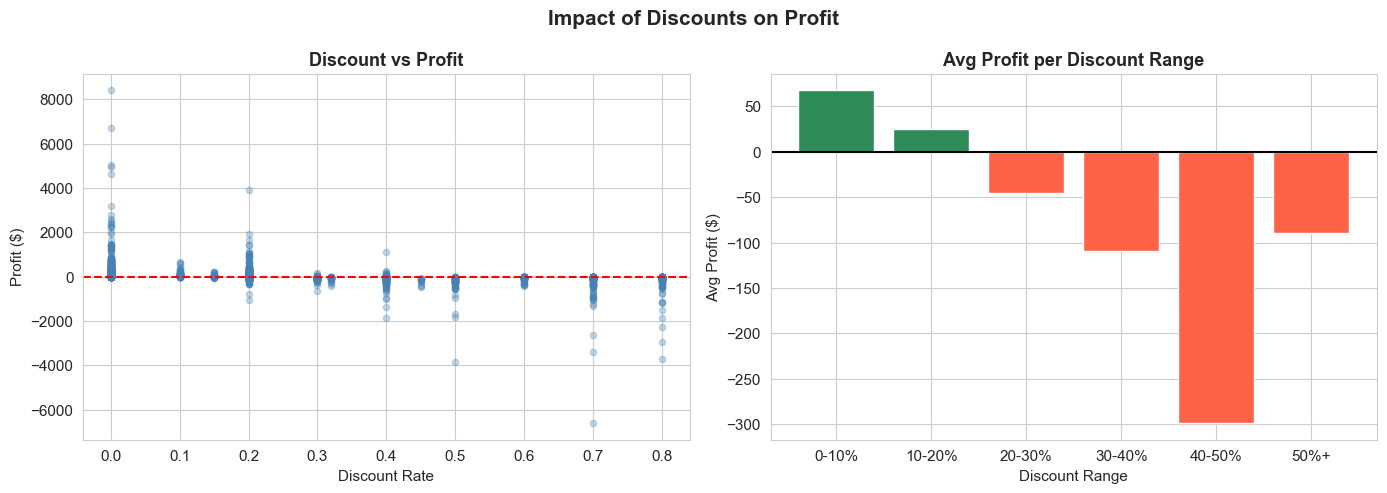

💡 Insight: High discounts (>20%) tend to result in negative profits!


In [17]:
# Does giving more discount hurt profit?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['Discount'], df['Profit'], alpha=0.3, color='steelblue', s=20)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Discount vs Profit', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Discount Rate')
axes[0].set_ylabel('Profit ($)')

# Average profit per discount bucket
df['Discount Bucket'] = pd.cut(df['Discount'], bins=[0,0.1,0.2,0.3,0.4,0.5,0.9],
                                labels=['0-10%','10-20%','20-30%','30-40%','40-50%','50%+'],
                                include_lowest=True)
disc_profit = df.groupby('Discount Bucket')['Profit'].mean().reset_index()
bar_colors = ['seagreen' if v >= 0 else 'tomato' for v in disc_profit['Profit']]
axes[1].bar(disc_profit['Discount Bucket'].astype(str), disc_profit['Profit'],
            color=bar_colors, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=1.5)
axes[1].set_title('Avg Profit per Discount Range', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Discount Range')
axes[1].set_ylabel('Avg Profit ($)')

plt.suptitle('Impact of Discounts on Profit', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print('💡 Insight: High discounts (>20%) tend to result in negative profits!')

## Step 9: Top 10 Products

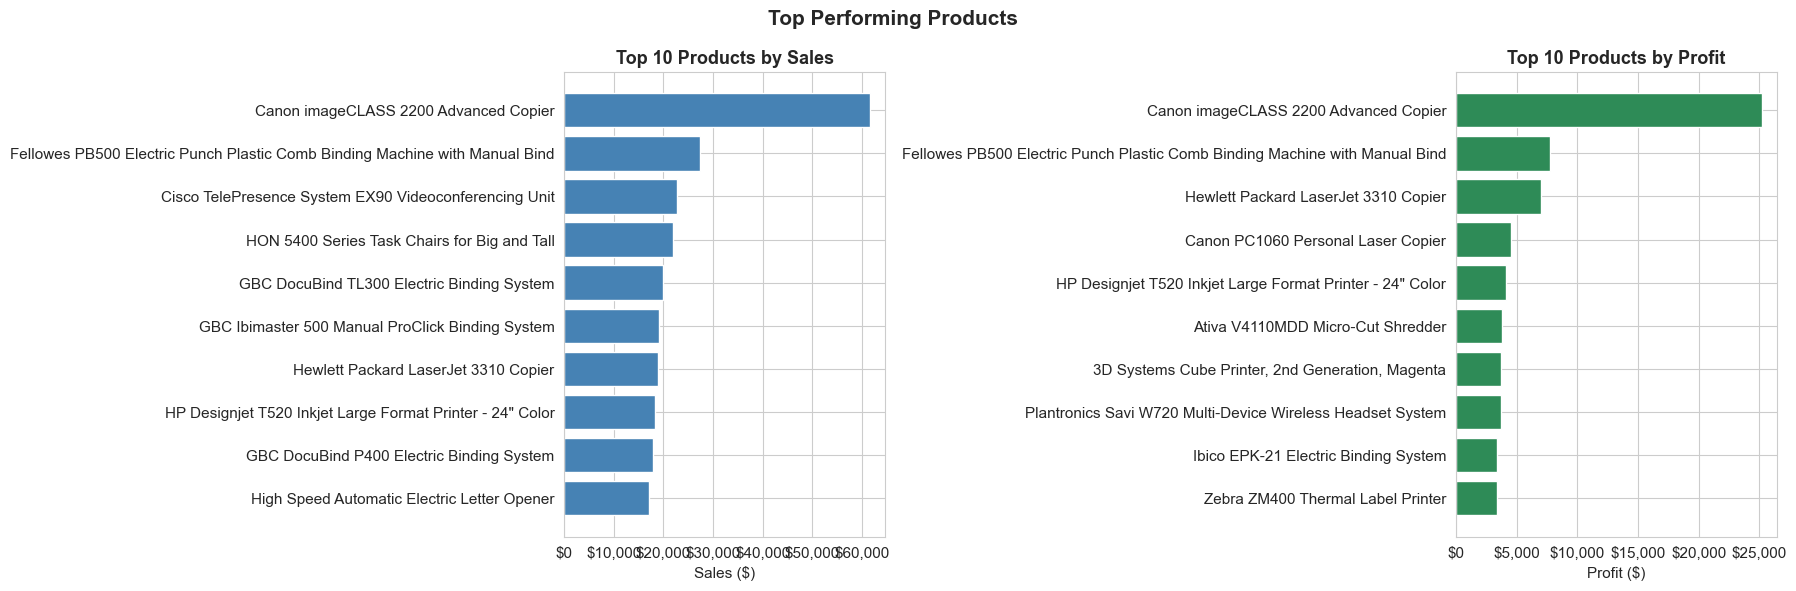

In [18]:
# Top 10 by Sales
top_sales = df.groupby('Product Name')['Sales'].sum().nlargest(10).reset_index()
top_profit = df.groupby('Product Name')['Profit'].sum().nlargest(10).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].barh(top_sales['Product Name'], top_sales['Sales'], color='steelblue', edgecolor='white')
axes[0].set_title('Top 10 Products by Sales', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sales ($)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].invert_yaxis()

axes[1].barh(top_profit['Product Name'], top_profit['Profit'], color='seagreen', edgecolor='white')
axes[1].set_title('Top 10 Products by Profit', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Profit ($)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].invert_yaxis()

plt.suptitle('Top Performing Products', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 10: Sales-to-Profit Ratio (Operational Efficiency)

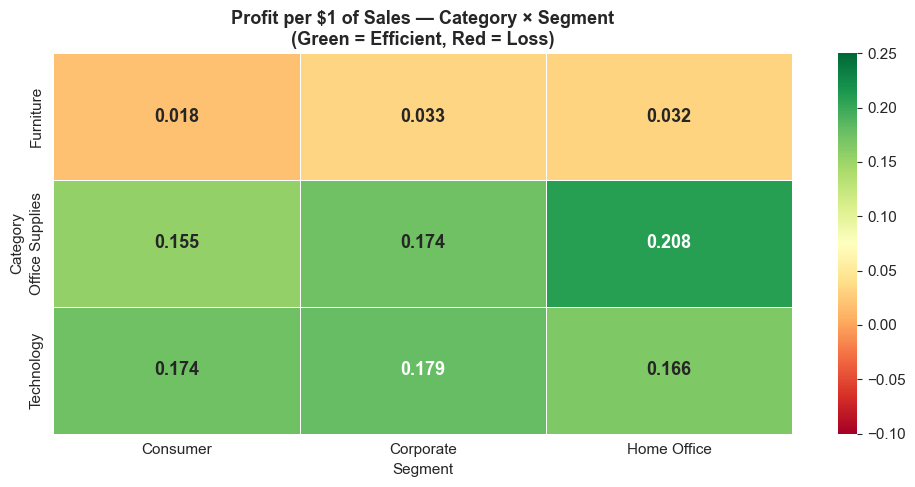

In [19]:
# How much profit does every $1 of sales generate?
efficiency = df.groupby(['Category','Segment'])[['Sales','Profit']].sum().reset_index()
efficiency['Profit per $1 Sales'] = (efficiency['Profit'] / efficiency['Sales']).round(3)

pivot = efficiency.pivot(index='Category', columns='Segment', values='Profit per $1 Sales')

plt.figure(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn',
            linewidths=0.5, annot_kws={'size': 13, 'weight': 'bold'},
            vmin=-0.1, vmax=0.25)
plt.title('Profit per $1 of Sales — Category × Segment\n(Green = Efficient, Red = Loss)', 
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## ✅ Step 11: Key Business Insights Summary

In [20]:
best_cat    = cat.loc[cat['Profit'].idxmax(), 'Category']
worst_cat   = cat.loc[cat['Profit'].idxmin(), 'Category']
best_region = region.loc[region['Profit'].idxmax(), 'Region']
best_seg    = seg.loc[seg['Profit'].idxmax(), 'Segment']
loss_subcats = subcat[subcat['Profit'] < 0]['Sub-Category'].tolist()

print('='*60)
print('        📋 KEY BUSINESS INSIGHTS')
print('='*60)
print(f'  ✅ Most Profitable Category  : {best_cat}')
print(f'  ⚠️  Least Profitable Category : {worst_cat}')
print(f'  ✅ Best Performing Region     : {best_region}')
print(f'  ✅ Most Profitable Segment    : {best_seg}')
print(f'  ❌ Loss-making Sub-Categories : {", ".join(loss_subcats)}')
print(f'  💡 Discounts above 20% lead to consistent losses')
print(f'  📈 Sales grow year-over-year — business is expanding')
print('='*60)

        📋 KEY BUSINESS INSIGHTS
  ✅ Most Profitable Category  : Technology
  ⚠️  Least Profitable Category : Furniture
  ✅ Best Performing Region     : West
  ✅ Most Profitable Segment    : Consumer
  ❌ Loss-making Sub-Categories : Tables, Bookcases, Supplies
  💡 Discounts above 20% lead to consistent losses
  📈 Sales grow year-over-year — business is expanding


## Summary

| Step | What we did |
|------|-------------|
| 1–2 | Loaded data, converted dates, created new features |
| 3 | Computed overall KPIs (Sales, Profit, Orders, Customers) |
| 4 | Analyzed monthly and yearly sales & profit trends |
| 5 | Identified top/bottom performing categories and sub-categories |
| 6 | Compared profitability across customer segments |
| 7 | Evaluated regional performance |
| 8 | Showed that high discounts destroy profit |
| 9 | Found top 10 products by sales and profit |
| 10 | Computed sales-to-profit efficiency heatmap |
| 11 | Summarized all key business insights |